In [1]:
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import easyocr

from ultralytics import YOLO

from py_files.detection import extract_plate
from py_files.preprocessing import preprocess_plate
from py_files.ocr import recognize_plate

In [2]:
model = YOLO("../models/best.pt")

reader = easyocr.Reader(
    ["en"],
    gpu=False
)

Using CPU. Note: This module is much faster with a GPU.


In [3]:
val_folder = Path("../data/cars/images/val")

images = list(val_folder.glob("*.jpg"))

print(len(images))

1073


In [4]:
random.seed(42)

sample_images = random.sample(
    images,
    20
)

len(sample_images)

20

In [5]:
methods = [
    "baseline",
    "equalize",
    "clahe",
    "otsu",
    "adaptive",
    "clahe_otsu"
]

In [6]:
rows = []

for image_path in sample_images:

    plates = extract_plate(
        image_path,
        model
    )

    if len(plates) == 0:
        continue

    plate = plates[0]

    for sr in [False, True]:

        for method in methods:

            processed = preprocess_plate(
                plate,
                method=method,
                use_super_resolution=sr
            )

            text, conf = recognize_plate(
                processed,
                reader
            )

            rows.append({

                "image": image_path.name,
                "super_resolution": sr,
                "method": method,
                "prediction": text,
                "confidence": conf

            })

C:\Users\User\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [7]:
results = pd.DataFrame(rows)
results.head()

,image,super_resolution,method,prediction,confidence
0,2c602008a22124be.jpg,False,baseline,NaN,NaN
1,2c602008a22124be.jpg,False,equalize,5541796,0.058518
2,2c602008a22124be.jpg,False,clahe,05573736,0.232283
3,2c602008a22124be.jpg,False,otsu,NaN,NaN
4,2c602008a22124be.jpg,False,adaptive,0554376,0.313031


In [8]:
results.groupby(
    ["super_resolution", "method"]
)["confidence"].mean().sort_values(
    ascending=False
)

super_resolution  method    
True              baseline      0.611293
                  otsu          0.595921
                  equalize      0.580404
                  clahe         0.572365
                  clahe_otsu    0.491345
False             baseline      0.478729
                  otsu          0.452963
                  equalize      0.445820
                  clahe         0.408495
True              adaptive      0.352184
False             adaptive      0.303822
                  clahe_otsu    0.285314
Name: confidence, dtype: float64

<Figure size 1000x500 with 0 Axes>

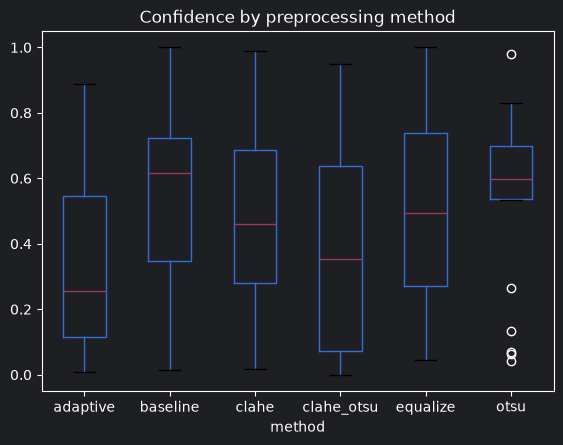

In [9]:
plt.figure(figsize=(10,5))

results.boxplot(
    column="confidence",
    by="method",
    grid=False
)

plt.suptitle("")
plt.title("Confidence by preprocessing method")

plt.show()

In [10]:
results.groupby(
    ["super_resolution","method"]
)["confidence"].describe()

count      mean       std       min       25%  \
super_resolution method                                                      
False            adaptive     16.0  0.303822  0.259841  0.007954  0.066979   
                 baseline     13.0  0.478729  0.269055  0.014642  0.271691   
                 clahe        14.0  0.408495  0.268701  0.016005  0.236647   
                 clahe_otsu   16.0  0.285314  0.291267  0.000000  0.033053   
                 equalize     13.0  0.445820  0.302294  0.058518  0.203991   
                 otsu          9.0  0.452963  0.284135  0.042252  0.134278   
True             adaptive     15.0  0.352184  0.264644  0.021385  0.174796   
                 baseline     14.0  0.611293  0.248117  0.151499  0.460693   
                 clahe        14.0  0.572365  0.283668  0.129115  0.400967   
                 clahe_otsu   13.0  0.491345  0.285241  0.032548  0.261224   
                 equalize     14.0  0.580404  0.300426  0.045326  0.413451   
                 otsu         13.0  0.595921  0.230984  0.064034  0.558635   

                                  50%       75%       max  
super_resolution method                                    
False            adaptive    0.264808  0.506674  0.887327  
                 baseline    0.495636  0.718366  0.824022  
                 clahe       0.375747  0.545741  0.968336  
                 clahe_otsu  0.150816  0.488809  0.898379  
                 equalize    0.435999  0.554229  0.992556  
                 otsu        0.587076  0.655468  0.709499  
True             adaptive    0.254565  0.555218  0.825941  
                 baseline    0.632120  0.723339  0.999883  
                 clahe       0.546372  0.765644  0.987437  
                 clahe_otsu  0.517101  0.676780  0.947698  
                 equalize    0.553505  0.847598  0.999839  
                 otsu        0.600085  0.701625  0.981022

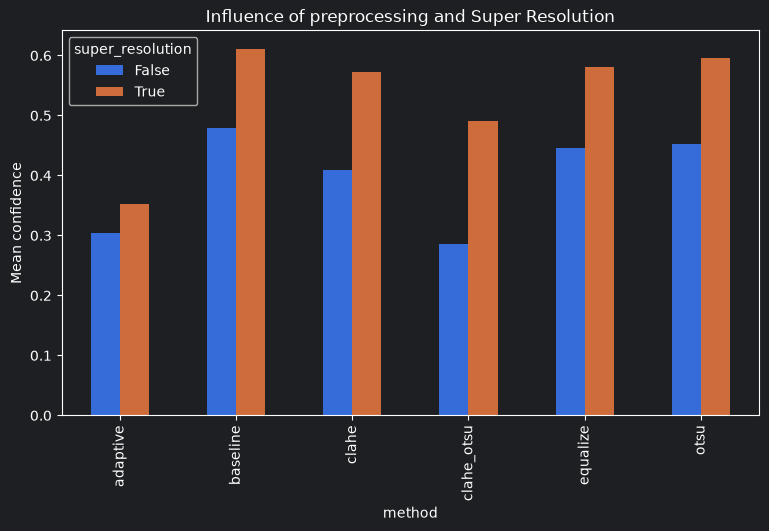

In [11]:
pivot = results.pivot_table(

    values="confidence",

    index="method",

    columns="super_resolution",

    aggfunc="mean"

)

pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.ylabel("Mean confidence")

plt.title("Influence of preprocessing and Super Resolution")

plt.show()

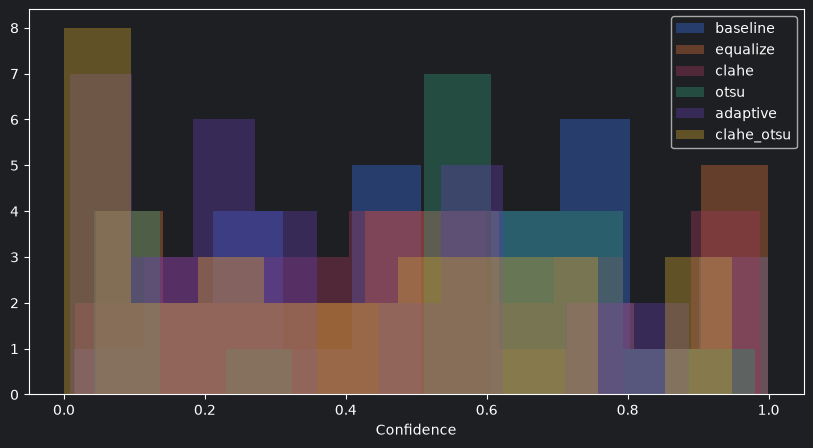

In [12]:
plt.figure(figsize=(10,5))

for method in methods:

    subset = results[
        results.method == method
    ]

    plt.hist(
        subset.confidence,
        bins=10,
        alpha=0.4,
        label=method
    )

plt.legend()

plt.xlabel("Confidence")

plt.show()

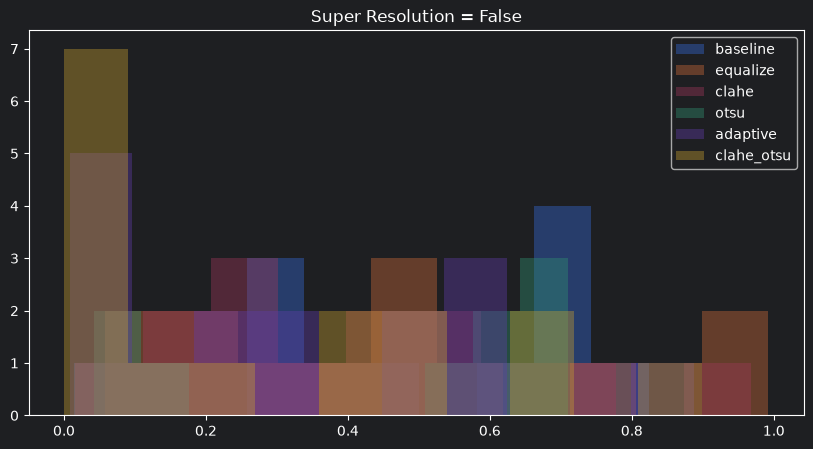

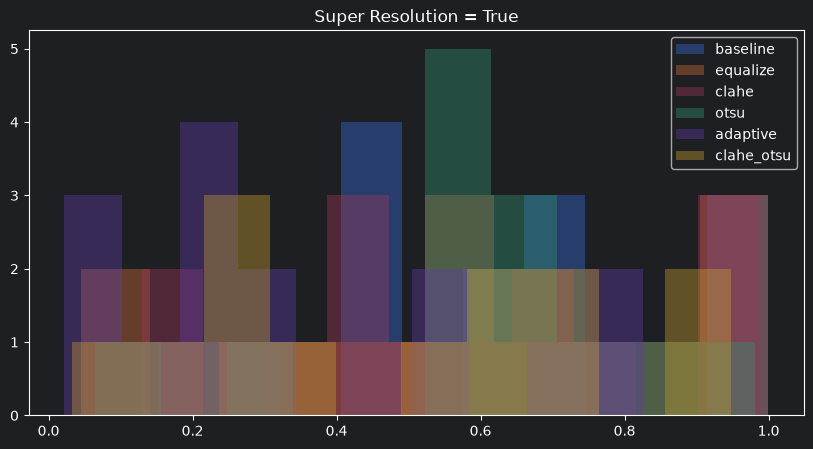

In [13]:
for sr in [False, True]:

    plt.figure(figsize=(10,5))

    for method in methods:

        subset = results[
            (results.method == method) &
            (results.super_resolution == sr)
        ]

        plt.hist(
            subset.confidence,
            bins=10,
            alpha=0.4,
            label=method
        )

    plt.title(f"Super Resolution = {sr}")

    plt.legend()

    plt.show()

In [14]:
best = (
    results
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(10)
)

best

,image,super_resolution,method,prediction,confidence
114,06bf917a1448f872.jpg,True,baseline,FINMUN,0.999883
91,206d435893a70789.jpg,True,equalize,2866HHM,0.999839
85,206d435893a70789.jpg,False,equalize,2866HHM,0.992556
200,5c55cf36942578fd.jpg,True,clahe,X458FCB,0.987437
213,c98faf510dea2441.jpg,True,otsu,ETW855T,0.981022
110,06bf917a1448f872.jpg,False,clahe,IFINMUN,0.968336
198,5c55cf36942578fd.jpg,True,baseline,X458FCB,0.963284
20,03ae238ae9016ff5.jpg,True,clahe,6V6527,0.958473
119,06bf917a1448f872.jpg,True,clahe_otsu,FWMUN,0.947698
199,5c55cf36942578fd.jpg,True,equalize,X458FCB,0.942251


In [15]:
best.groupby(
    ["super_resolution","method"]
).size()

super_resolution  method    
False             clahe         1
                  equalize      1
True              baseline      2
                  clahe         2
                  clahe_otsu    1
                  equalize      2
                  otsu          1
dtype: int64

In [16]:
worst = (
    results
    .sort_values(
        "confidence"
    )
    .head(10)
)

worst

,image,super_resolution,method,prediction,confidence
53,695582dbb6b564bc.jpg,False,clahe_otsu,,0.000000
16,03ae238ae9016ff5.jpg,False,adaptive,690F,0.007954
137,23fa8a0b6d60d9a0.jpg,False,clahe_otsu,5ZED,0.010393
132,23fa8a0b6d60d9a0.jpg,False,baseline,43150284110,0.014642
98,cafc97ebc49704ba.jpg,False,clahe,6697932,0.016005
28,83c416344cb2ae4e.jpg,False,adaptive,VEIO,0.018386
136,23fa8a0b6d60d9a0.jpg,False,adaptive,07ID,0.020139
142,23fa8a0b6d60d9a0.jpg,True,adaptive,K50R2B4A1D,0.021385
5,2c602008a22124be.jpg,False,clahe_otsu,M385,0.024048
125,063b8572725e4df0.jpg,False,clahe_otsu,PRFR,0.024202


In [17]:
worst.groupby(
    ["super_resolution","method"]
).size()

super_resolution  method    
False             adaptive      3
                  baseline      1
                  clahe         1
                  clahe_otsu    4
True              adaptive      1
dtype: int64